In [1]:
import os
import sys
import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

torch.manual_seed(42)

In [2]:
# src_path = os.path.abspath('/home/fabihat/phd_quaid/2603_dl_prj/ATAC_denoising/src')
src_path = os.path.abspath('/data1/peerd/paddockl/projects/DL_project/ATAC_denoising/src')
sys.path.append(src_path)

In [3]:
from atac_dataset import create_dataloader
from model import DAE

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
dataloader = create_dataloader(dense_dir = "/data1/peerd/paddockl/projects/DL_project/ATAC_denoising/data/ENCODE_ATAC_chr19_Counts",
                              sparse_dir = "/data1/peerd/paddockl/projects/DL_project/ATAC_denoising/data/atac_chr19_subsampled",
                              batch_size = 7,
                              num_workers = 2,
                              sparsity = 0.5)

# dataloader = create_dataloader(dense_dir = "/home/fabihat/phd_quaid/2603_dl_prj/data/ENCODE_ATAC_chr19_Counts",
#                                sparse_dir = "/home/fabihat/phd_quaid/2603_dl_prj/data/atac_chr19_subsampled",
#                                batch_size = 7)

In [6]:
from plot import plot_bin_counts

In [7]:

x, y = next(iter(dataloader))

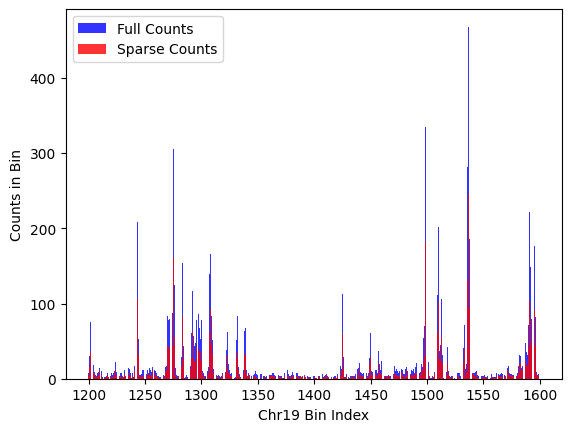

In [8]:
f = plot_bin_counts(x[0],y[0], bin_range = (1200,1600))

In [ ]:
#hidden dim 1024, Epoch 100 | Loss: 1590.0474
#hidden dim 4096, Epoch 100 | Loss: 1265.1044
#hidden dim 8192, Epoch 500  | Loss: 819.8657

In [6]:
def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    # reconstruction loss
    recon_loss = F.mse_loss(x_hat, x, reduction='mean')

    # KL divergence
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + beta * kl, recon_loss, kl

In [7]:
def train_vae(
    model,
    dataloader,
    device,
    epochs=500,
    lr=1e-3,
    beta_start=0.0,
    beta_end=1.0,
    beta_warmup=100,
):
    optimizer = Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        total_recon = 0
        total_kl = 0

        # β annealing (VERY important for stability)
        if epoch < beta_warmup:
            beta = beta_start + (beta_end - beta_start) * (epoch / beta_warmup)
        else:
            beta = beta_end

        for x, y in dataloader:
            x = x.to(device).float()   # sparsified input
            y = y.to(device).float()   # original bulk (target)

            # forward pass
            x_hat, mu, logvar = model(x)

            # loss
            loss, recon_loss, kl = vae_loss(x_hat, y, mu, logvar, beta=beta)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl.item()

        avg_loss = total_loss / len(dataloader)
        avg_recon = total_recon / len(dataloader)
        avg_kl = total_kl / len(dataloader)

        print(
            f"Epoch {epoch+1:03d} | "
            f"Loss: {avg_loss:.4f} | "
            f"Recon: {avg_recon:.4f} | "
            f"KL: {avg_kl:.4f} | "
            f"Beta: {beta:.4f}"
        )

In [8]:
model = DAE().to(device)

train_vae(
    model,
    dataloader,
    device,
    epochs=500,
    lr=1e-3
)

/home/fabihat/micromamba/envs/DL_project/lib/python3.13/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 001 | Loss: 2787.4910 | Recon: 2787.4910 | KL: 0.1600 | Beta: 0.0000
Epoch 002 | Loss: 2642.9862 | Recon: 2642.9843 | KL: 0.1882 | Beta: 0.0100
Epoch 003 | Loss: 2493.7527 | Recon: 2493.7484 | KL: 0.2118 | Beta: 0.0200
Epoch 004 | Loss: 2372.2987 | Recon: 2372.2913 | KL: 0.2454 | Beta: 0.0300
Epoch 005 | Loss: 2252.2491 | Recon: 2252.2390 | KL: 0.2552 | Beta: 0.0400
Epoch 006 | Loss: 2147.8720 | Recon: 2147.8576 | KL: 0.2884 | Beta: 0.0500
Epoch 007 | Loss: 2182.6252 | Recon: 2182.6069 | KL: 0.3046 | Beta: 0.0600
Epoch 008 | Loss: 1914.8345 | Recon: 1914.8117 | KL: 0.3256 | Beta: 0.0700
Epoch 009 | Loss: 1833.9837 | Recon: 1833.9537 | KL: 0.3751 | Beta: 0.0800
Epoch 010 | Loss: 1726.0820 | Recon: 1726.0473 | KL: 0.3858 | Beta: 0.0900
Epoch 011 | Loss: 1671.8384 | Recon: 1671.7961 | KL: 0.4224 | Beta: 0.1000
Epoch 012 | Loss: 1559.6969 | Recon: 1559.6469 | KL: 0.4542 | Beta: 0.1100
Epoch 013 | Loss: 1536.5785 | Recon: 1536.5244 | KL: 0.4512 | Beta: 0.1200
Epoch 014 | Loss: 1376.51

KeyboardInterrupt: 

In [11]:
f = "/home/fabihat/phd_quaid/2603_dl_prj/data/atac_chr19_subsampled/ENCFF738VXT.chr19_bins.tsv.gz"
df = pd.read_csv(f, sep="\t")

In [12]:
sparsity=1
cols = [i for i in df.columns if f"_{sparsity}_" in i]
print(cols)

['ENCFF738VXT_1_42', 'ENCFF738VXT_1_123', 'ENCFF738VXT_1_999']


In [14]:
df[cols]

,ENCFF738VXT_1_42,ENCFF738VXT_1_123,ENCFF738VXT_1_999
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
109787,0,0,0
109788,0,0,0
109789,0,0,0
109790,0,0,0


In [14]:
f = "/home/fabihat/phd_quaid/2603_dl_prj/data/ENCODE_ATAC_chr19_Counts/ENCFF858GSU.chr19_bins.tsv.gz"
df = pd.read_csv(f, sep="\t")

In [15]:
df

,bin,ENCFF858GSU
0,chr19:271500-272000,2
1,chr19:272000-272500,3
2,chr19:272500-273000,2
3,chr19:273000-273500,3
4,chr19:273500-274000,5
...,...,...
109787,chr19:58536000-58536500,0
109788,chr19:58536500-58537000,4
109789,chr19:58537000-58537500,5
109790,chr19:58537500-58538000,4
